In [1]:
from pathlib import Path
import math
import numpy as np
import pandas as pd
import sys
import os
import re

# ../bin/AnalysisVSPAERO.py をモジュールとしてインポート
sys.path.append(os.path.join('../../../')) # 親ディレクトリをモジュール探索パスに追加
from src.VvGammaChart import (
    collect_vv_wtip_sweep_progress,
    plot_vv_gamma_contour_panel,
    postprocess_vv_gamma_cases,
    run_vv_wtip_stability_sweep,
)

In [2]:
base_vsp3_path = Path('../../models/SampleGlider/SampleGlider.0G.vsp3')
output_dir = Path('')

# vv_values = np.linspace(0.001, 0.006, 11)
# tip_deflections = np.linspace(0.0, 2.0, 11)

# Set these to sequences such as np.linspace(...) when fixed axis ticks are desired.
VV_TICKS = np.linspace(0.001,0.006,6)
GAMMA_TICKS = np.linspace(0,8,9)

GRID_SIZE = 256
LEVELS = 256
METHOD = "linear"
FALLBACK_METHOD = "nearest"
SHOW_POINTS = False

COLORBAR_TICKS_BY_COLUMN = {
    "simple_rudder_limit_turn_max_abs_phi" : np.linspace(0, 7, 8),
    "rudder_limit_turn_max_abs_phi" : np.linspace(0, 7, 8),
    "turn_trim_delta_r" : np.linspace(-10, 10, 11),
    "simple_rudder_turn_K_phi" : np.linspace(0, 0.62264444, 8),
}

PANEL_KWARGS = dict(
    grid_size=GRID_SIZE,
    levels=LEVELS,
    method=METHOD,
    fallback_method=FALLBACK_METHOD,
    colorbar_ticks_by_column=COLORBAR_TICKS_BY_COLUMN,
    x_ticks=VV_TICKS,
    y_ticks=GAMMA_TICKS,
    show_points=SHOW_POINTS,
    show_colorbar=True,
)


In [3]:

VV_WTIP_CASE_PATTERN = re.compile(
    r"^vv_(m?\d+p\d{5})_wtip_(m?\d+p\d{5})$"
)

output_dir = Path(output_dir)
cases = []

for path in output_dir.iterdir():
    if not path.is_dir():
        continue

    match = VV_WTIP_CASE_PATTERN.fullmatch(path.name)
    if match is None:
        continue

    vv = float(match.group(1).replace("m", "-").replace("p", "."))
    tip_deflection = float(
        match.group(2).replace("m", "-").replace("p", ".")
    )
    cases.append((vv, tip_deflection))

if not cases:
    raise FileNotFoundError(
        f"Vv/wtip case directories were not found in {output_dir}."
    )

vv_values = np.array(
    sorted({vv for vv, _ in cases}),
    dtype=float,
)
tip_deflections = np.array(
    sorted({tip_deflection for _, tip_deflection in cases}),
    dtype=float,
)
np.set_printoptions(linewidth=999)
print(f"vv_values       = {vv_values}")
print(f"tip_deflections = {tip_deflections}")

vv_values       = [0.001  0.0015 0.002  0.0025 0.003  0.0035 0.004  0.0045 0.005  0.0055 0.006 ]
tip_deflections = [0.  0.1 0.2 0.3 0.4 0.5 0.6 0.7 0.8 0.9 1.  1.1 1.2 1.3 1.4 1.5 1.6 1.7 1.8 1.9 2. ]


In [4]:
sweep = collect_vv_wtip_sweep_progress(
    vv_values,
    tip_deflections,
    output_dir,
    gamma_semispan=13.5,
    include_incomplete_cases=False,
    output_csv_path=output_dir / 'vv_wtip_stability_sweep_progress.csv',
)


## 0. パラメータ計算

In [5]:

repo_root = Path(r"C:\Users\mtkbirdman\OneDrive\Documents\OpenVSP")
notebook_root = repo_root / "examples" / "notebooks" / "vv_gamma_chart"

if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from src.VvGammaChart import postprocess_vv_gamma_cases

# 入力CSV
# 通常は run_vv_wtip_stability_sweep() の出力を使う。
# 収束確認後に収束ケースだけに絞ったCSVを作った場合は、そちらを使う。
input_csv = notebook_root / "vv_wtip_stability_sweep_progress.csv"

output_csv = notebook_root / "vv_gamma_chart.csv"
history_output_dir = notebook_root / "6dof_histories"

print("input_csv :", input_csv)
print("output_csv:", output_csv)
print("history  :", history_output_dir)

# ============================================================
# 2. 機体条件
# ============================================================
# 単位系は .stab と必ず合わせる。
# .stab が SI 系なら、mass[kg], inertia[kg m^2], Uds[m/s], H[m]。

mass = 100.0
inertia = {
    'Ixx': 1000.0,
    'Iyy': 75.0,
    'Izz': 1000.0,
    'Ixz': 0.0,
}

# ============================================================
# 3. ラダー横転性能の評価条件
# ============================================================

delta_r = math.radians(-10.0)
target_delta_phi = math.radians(+2.0)

t_final = 99.0
max_step = 0.01

# 初期トリム・簡易ピッチ保持
delta_a = 0.0
delta_e = None
trim_elevator = True

theta_hold = True
theta_hold_kp = 0.3
theta_hold_kq = 0.8

trim_thrust = True

# ============================================================
# 4. 定常旋回トリム条件
# ============================================================
# glider 想定なら gliding が自然。
# 水平飛行・推力ありで見るなら level。
# 不要な評価は mode="none" にする。

# ------------------------------------------------------------
# 4-1. 固定バンク角トリム
# ------------------------------------------------------------
# V=.stab の Vinf、phi=turn_trim_phi、delta_a=0 を固定し、
# 指定バンク角で釣り合うために必要な delta_r などを求める。
# 最大バンク角指標の妥当性確認にも使用する。

turn_trim_mode = "gliding"
turn_trim_phi = math.radians(+2.0)
turn_trim_delta_a = 0.0
turn_trim_bounds = (
    {
        "alpha":   math.radians( -4.0),
        # "beta":    math.radians(-20.0),
        "theta":   math.radians(-10.0),
        "delta_e": math.radians(-20.0),
        "delta_r": math.radians(-30.0),
    },
    {
        "alpha":   math.radians( 4.0),
        # "beta":    math.radians(20.0),
        "theta":   math.radians(10.0),
        "delta_e": math.radians(20.0),
        "delta_r": math.radians(30.0),
    },
)

# ------------------------------------------------------------
# 4-2. ラダー舵角限界トリム
# ------------------------------------------------------------
# delta_r=±delta_r_max の両端でトリムを解き、
# 成立した解のうち abs(phi) が大きい側を最大バンク角候補とする。
#
# delta_r は固定値なので bounds には含めない。
# phi の bounds に達した場合は、最大値ではなく探索境界で
# 打ち切られた可能性があるため、範囲を見直す。

rudder_limit_turn_mode = "gliding"
rudder_limit_turn_delta_r_max = math.radians(10.0)
rudder_limit_turn_delta_a = 0.0
rudder_limit_turn_bounds = (
    {
        "alpha":   math.radians( -4.0),
        "beta":    math.radians(-20.0),
        "phi":     math.radians(-60.0),
        "theta":   math.radians(-10.0),
        "delta_e": math.radians(-10.0),
    },
    {
        "alpha":   math.radians( 4.0),
        "beta":    math.radians(20.0),
        "phi":     math.radians(60.0),
        "theta":   math.radians(10.0),
        "delta_e": math.radians(10.0),
    },
)

# ============================================================
# 5. 横風突風6DOF条件
# ============================================================
# 1-cosine gust:
# Uds: 符号付きの有次元ピーク突風速度
# Part 25 の EAS 値を使う場合は、解析高度の TAS 相当値へ変換する。
# H  : 突風勾配距離
#
crosswind_gust_Uds = 3.0
crosswind_gust_H = 30.0 * 0.3048

crosswind_gust_t_final = 3.0
crosswind_gust_start_time = 0.0

# 突風応答では、まず舵は中立で見る
crosswind_gust_delta_a = 0.0
crosswind_gust_delta_e = None
crosswind_gust_delta_r = 0.0

df = postprocess_vv_gamma_cases(
    input_csv,

    # --------------------------------------------------------
    # .stab path / Gamma_eff
    # --------------------------------------------------------
    stab_path_column="stab_path",
    # gamma_semispan=gamma_semispan,
    gamma_semispan_column="gamma_semispan",
    gamma_n_span=1001,

    # --------------------------------------------------------
    # control group 対応
    # Noneなら .stab 内の control group 名から
    # AILERON / ELEVATOR / RUDDER を自動推定する。
    # うまくいかない場合は明示する。
    # 例:
    # control_map={
    #     "delta_a": "AILERON_GROUP",
    #     "delta_e": "ELEVATOR_GROUP",
    #     "delta_r": "RUDDER_GROUP",
    # },
    # または
    # control_map={
    #     "delta_a": "ConGrp_1",
    #     "delta_e": "ConGrp_2",
    #     "delta_r": "ConGrp_3",
    # },
    # --------------------------------------------------------
    control_map=None,

    # --------------------------------------------------------
    # 質量・慣性・大気
    # --------------------------------------------------------
    mass=mass,
    inertia=inertia,
    rho=None,          # Noneなら .stab の Rho を使用
    g=9.80665,

    # --------------------------------------------------------
    # 簡易ラダー横転指数
    # --------------------------------------------------------
    # simple_rudder_roll_index は .stab の安定微係数から自動計算される。

    # --------------------------------------------------------
    # 6DOF ラダーステップ応答
    # --------------------------------------------------------
    run_6dof=True,
    delta_r=delta_r,
    target_delta_phi=target_delta_phi,
    stop_6dof_at_target_delta_phi=True,
    t_final=t_final,

    # --------------------------------------------------------
    # 舵・初期トリム・簡易ピッチ保持
    # --------------------------------------------------------
    delta_a=delta_a,
    delta_e=delta_e,
    trim_elevator=trim_elevator,

    theta_hold=theta_hold,
    theta_ref=None,
    theta_hold_kp=theta_hold_kp,
    theta_hold_kq=theta_hold_kq,
    delta_e_min=math.radians(-20.0),
    delta_e_max=math.radians(20.0),

    thrust=None,
    trim_thrust=trim_thrust,

    phi0=0.0,
    theta0=None,
    psi0=0.0,

    max_step=max_step,
    rtol=1.0e-8,
    atol=1.0e-10,

    # --------------------------------------------------------
    # 固定バンク角トリム
    # --------------------------------------------------------
    turn_trim_mode=turn_trim_mode,
    turn_trim_phi=turn_trim_phi,
    turn_trim_delta_a=turn_trim_delta_a,
    turn_trim_initial_guess=None,
    turn_trim_bounds=turn_trim_bounds,
    turn_trim_residual_tol=1.0e-6,

    # --------------------------------------------------------
    # ラダー舵角限界における最大バンク角候補
    # --------------------------------------------------------
    rudder_limit_turn_mode=rudder_limit_turn_mode,
    rudder_limit_turn_delta_r_max=rudder_limit_turn_delta_r_max,
    rudder_limit_turn_delta_a=rudder_limit_turn_delta_a,
    rudder_limit_turn_initial_guess=None,
    rudder_limit_turn_bounds=rudder_limit_turn_bounds,
    rudder_limit_turn_residual_tol=1.0e-6,

    # --------------------------------------------------------
    # ラダーステップ6DOF履歴保存
    # --------------------------------------------------------
    write_6dof_history=True,
    plot_6dof_history=True,

    # --------------------------------------------------------
    # 横風突風6DOF
    # --------------------------------------------------------
    run_crosswind_gust_6dof=True,
    crosswind_gust_Uds=crosswind_gust_Uds,
    crosswind_gust_H=crosswind_gust_H,
    crosswind_gust_t_final=crosswind_gust_t_final,
    crosswind_gust_start_time=crosswind_gust_start_time,
    crosswind_gust_delta_a=crosswind_gust_delta_a,
    crosswind_gust_delta_e=crosswind_gust_delta_e,
    crosswind_gust_delta_r=crosswind_gust_delta_r,

    # --------------------------------------------------------
    # 横風突風6DOF履歴保存
    # --------------------------------------------------------
    write_crosswind_gust_history=True,
    plot_crosswind_gust_history=True,

    # --------------------------------------------------------
    # 出力
    # --------------------------------------------------------
    history_output_dir=history_output_dir,
    output_csv_path=output_csv,

    verbose=2,
)


input_csv : C:\Users\mtkbirdman\OneDrive\Documents\OpenVSP\examples\notebooks\vv_gamma_chart\vv_wtip_stability_sweep_progress.csv
output_csv: C:\Users\mtkbirdman\OneDrive\Documents\OpenVSP\examples\notebooks\vv_gamma_chart\vv_gamma_chart.csv
history  : C:\Users\mtkbirdman\OneDrive\Documents\OpenVSP\examples\notebooks\vv_gamma_chart\6dof_histories
[2026-07-12 21:58:52] Basic .stab indices start: vv_0p00100_wtip_0p00000\vv_0p00100_wtip_0p00000.stab
[2026-07-12 21:59:06] Basic .stab indices start: vv_0p00100_wtip_0p10000\vv_0p00100_wtip_0p10000.stab
[2026-07-12 21:59:19] Basic .stab indices start: vv_0p00100_wtip_0p20000\vv_0p00100_wtip_0p20000.stab
[2026-07-12 22:00:08] Basic .stab indices start: vv_0p00100_wtip_0p30000\vv_0p00100_wtip_0p30000.stab
[2026-07-12 22:00:58] Basic .stab indices start: vv_0p00100_wtip_0p40000\vv_0p00100_wtip_0p40000.stab
[2026-07-12 22:01:48] Basic .stab indices start: vv_0p00100_wtip_0p50000\vv_0p00100_wtip_0p50000.stab
[2026-07-12 22:02:38] Basic .stab indic

## 1. import と入力CSV

CSV は以下の順で探す。

1. notebook と同じディレクトリ
2. 親ディレクトリ以下の同名CSV

配置が異なる場合は `csv_path` を直接書き換える。

In [6]:
from pathlib import Path
import ast
import os
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["mathtext.fontset"] = "stix"

# Repository root.  Adjust this if the notebook is moved.
sys.path.append(os.path.join("../../../"))
from src.VvGammaChart import plot_vv_gamma_contour_panel

csv_path = Path("vv_gamma_chart.csv")

output_dir = Path("vv_gamma_chart_plots")
output_dir.mkdir(parents=True, exist_ok=True)

print("csv_path:", csv_path.resolve())
print("output_dir:", output_dir.resolve())

csv_path: C:\Users\mtkbirdman\OneDrive\Documents\OpenVSP\examples\notebooks\vv_gamma_chart\vv_gamma_chart.csv
output_dir: C:\Users\mtkbirdman\OneDrive\Documents\OpenVSP\examples\notebooks\vv_gamma_chart\vv_gamma_chart_plots


In [7]:
df_raw = pd.read_csv(csv_path)
df = df_raw.copy()

required_axis_columns = {"Vv", "Gamma_eff_deg"}
missing_axis_columns = required_axis_columns - set(df.columns)
if missing_axis_columns:
    raise KeyError(f"vv_gamma_chart.csv is missing Vv-Gamma axis column(s): {sorted(missing_axis_columns)}")

if "passed" in df.columns:
    if df["passed"].dtype == bool:
        passed_mask = df["passed"]
    else:
        passed_mask = df["passed"].astype(str).str.lower().isin(["true", "1", "yes"])
    df = df[passed_mask].copy().reset_index(drop=True)

print("rows:", len(df))
print("Vv range:", float(df["Vv"].min()), "to", float(df["Vv"].max()))
print("Gamma_eff_deg range:", float(df["Gamma_eff_deg"].min()), "to", float(df["Gamma_eff_deg"].max()))
print("columns:", len(df.columns))
df.head()

rows: 231
Vv range: 0.001 to 0.006
Gamma_eff_deg range: 0.0 to 9.692678823088029
columns: 421


,case,case_index,case_count,Vv,tip_deflection,case_dir,gamma_semispan,vsp3_path,deflection_csv_path,stab_path,...,rudder_limit_turn_negative_beta,rudder_limit_turn_negative_phi,rudder_limit_turn_negative_Omega,rudder_limit_turn_negative_delta_r,rudder_limit_turn_positive_message,rudder_limit_turn_positive_max_abs_residual,rudder_limit_turn_positive_beta,rudder_limit_turn_positive_phi,rudder_limit_turn_positive_Omega,rudder_limit_turn_positive_delta_r
0,vv_0p00100_wtip_0p00000,1,231,0.001,0.0,vv_0p00100_wtip_0p00000,13.5,vv_0p00100_wtip_0p00000\vv_0p00100_wtip_0p0000...,vv_0p00100_wtip_0p00000\vv_0p00100_wtip_0p0000...,vv_0p00100_wtip_0p00000\vv_0p00100_wtip_0p0000...,...,-6.093511,0.027635,0.014137,-10.0,`gtol` termination condition is satisfied.,2.793171e-11,6.419157,0.024613,0.030959,10.0
1,vv_0p00100_wtip_0p10000,2,231,0.001,0.1,vv_0p00100_wtip_0p10000,13.5,vv_0p00100_wtip_0p10000\vv_0p00100_wtip_0p1000...,vv_0p00100_wtip_0p10000\vv_0p00100_wtip_0p1000...,vv_0p00100_wtip_0p10000\vv_0p00100_wtip_0p1000...,...,19.999702,1.535132,1.116626,-10.0,`gtol` termination condition is satisfied.,1.000226e-04,-19.998776,-1.519888,-1.116009,10.0
2,vv_0p00100_wtip_0p20000,3,231,0.001,0.2,vv_0p00100_wtip_0p20000,13.5,vv_0p00100_wtip_0p20000\vv_0p00100_wtip_0p2000...,vv_0p00100_wtip_0p20000\vv_0p00100_wtip_0p2000...,vv_0p00100_wtip_0p20000\vv_0p00100_wtip_0p2000...,...,5.943457,0.867071,0.640802,-10.0,`gtol` termination condition is satisfied.,3.530172e-08,-6.123833,-0.888355,-0.656099,10.0
3,vv_0p00100_wtip_0p30000,4,231,0.001,0.3,vv_0p00100_wtip_0p30000,13.5,vv_0p00100_wtip_0p30000\vv_0p00100_wtip_0p3000...,vv_0p00100_wtip_0p30000\vv_0p00100_wtip_0p3000...,vv_0p00100_wtip_0p30000\vv_0p00100_wtip_0p3000...,...,3.738283,0.757280,0.567993,-10.0,`gtol` termination condition is satisfied.,2.605402e-08,-3.839916,-0.776944,-0.580750,10.0
4,vv_0p00100_wtip_0p40000,5,231,0.001,0.4,vv_0p00100_wtip_0p40000,13.5,vv_0p00100_wtip_0p40000\vv_0p00100_wtip_0p4000...,vv_0p00100_wtip_0p40000\vv_0p00100_wtip_0p4000...,vv_0p00100_wtip_0p40000\vv_0p00100_wtip_0p4000...,...,2.594133,0.681082,0.509945,-10.0,`gtol` termination condition is satisfied.,2.401361e-10,-2.633012,-0.693415,-0.518211,10.0


In [8]:
def read_control_groups(value):
    if isinstance(value, dict):
        return value
    if pd.isna(value):
        return {}
    return ast.literal_eval(str(value))

control_groups = {}
if "control_groups" in df.columns and df["control_groups"].notna().any():
    control_groups = read_control_groups(df.loc[df["control_groups"].notna(), "control_groups"].iloc[0])

# Fallback is the G103A convention used in the current model.
delta_to_congrp = {
    "delta_a": "ConGrp_1",
    "delta_e": "ConGrp_2",
    "delta_r": "ConGrp_3",
}

for congrp, group_name in control_groups.items():
    name = str(group_name).upper()
    if "AILERON" in name:
        delta_to_congrp["delta_a"] = congrp
    elif "ELEVATOR" in name:
        delta_to_congrp["delta_e"] = congrp
    elif "RUDDER" in name:
        delta_to_congrp["delta_r"] = congrp

print("control_groups:", control_groups)
print("delta_to_congrp:", delta_to_congrp)

control_groups: {'ConGrp_1': 'AILERON_GROUP', 'ConGrp_2': 'ELEVATOR_GROUP', 'ConGrp_3': 'RUDDER_GROUP'}
delta_to_congrp: {'delta_a': 'ConGrp_1', 'delta_e': 'ConGrp_2', 'delta_r': 'ConGrp_3'}


In [9]:

def save_figure(fig, stem):
    fig.tight_layout()
    fig.savefig(output_dir / f"{stem}.png", dpi=200, bbox_inches="tight")
    fig.savefig(output_dir / f"{stem}.pdf", bbox_inches="tight")


## 7. 横・方向の空力微係数

列は左から $C_Y, C_l, C_n$、行は上から $\alpha, \beta, \hat p, \hat q, \hat r, \delta_e, \delta_a, \delta_r$ とする。

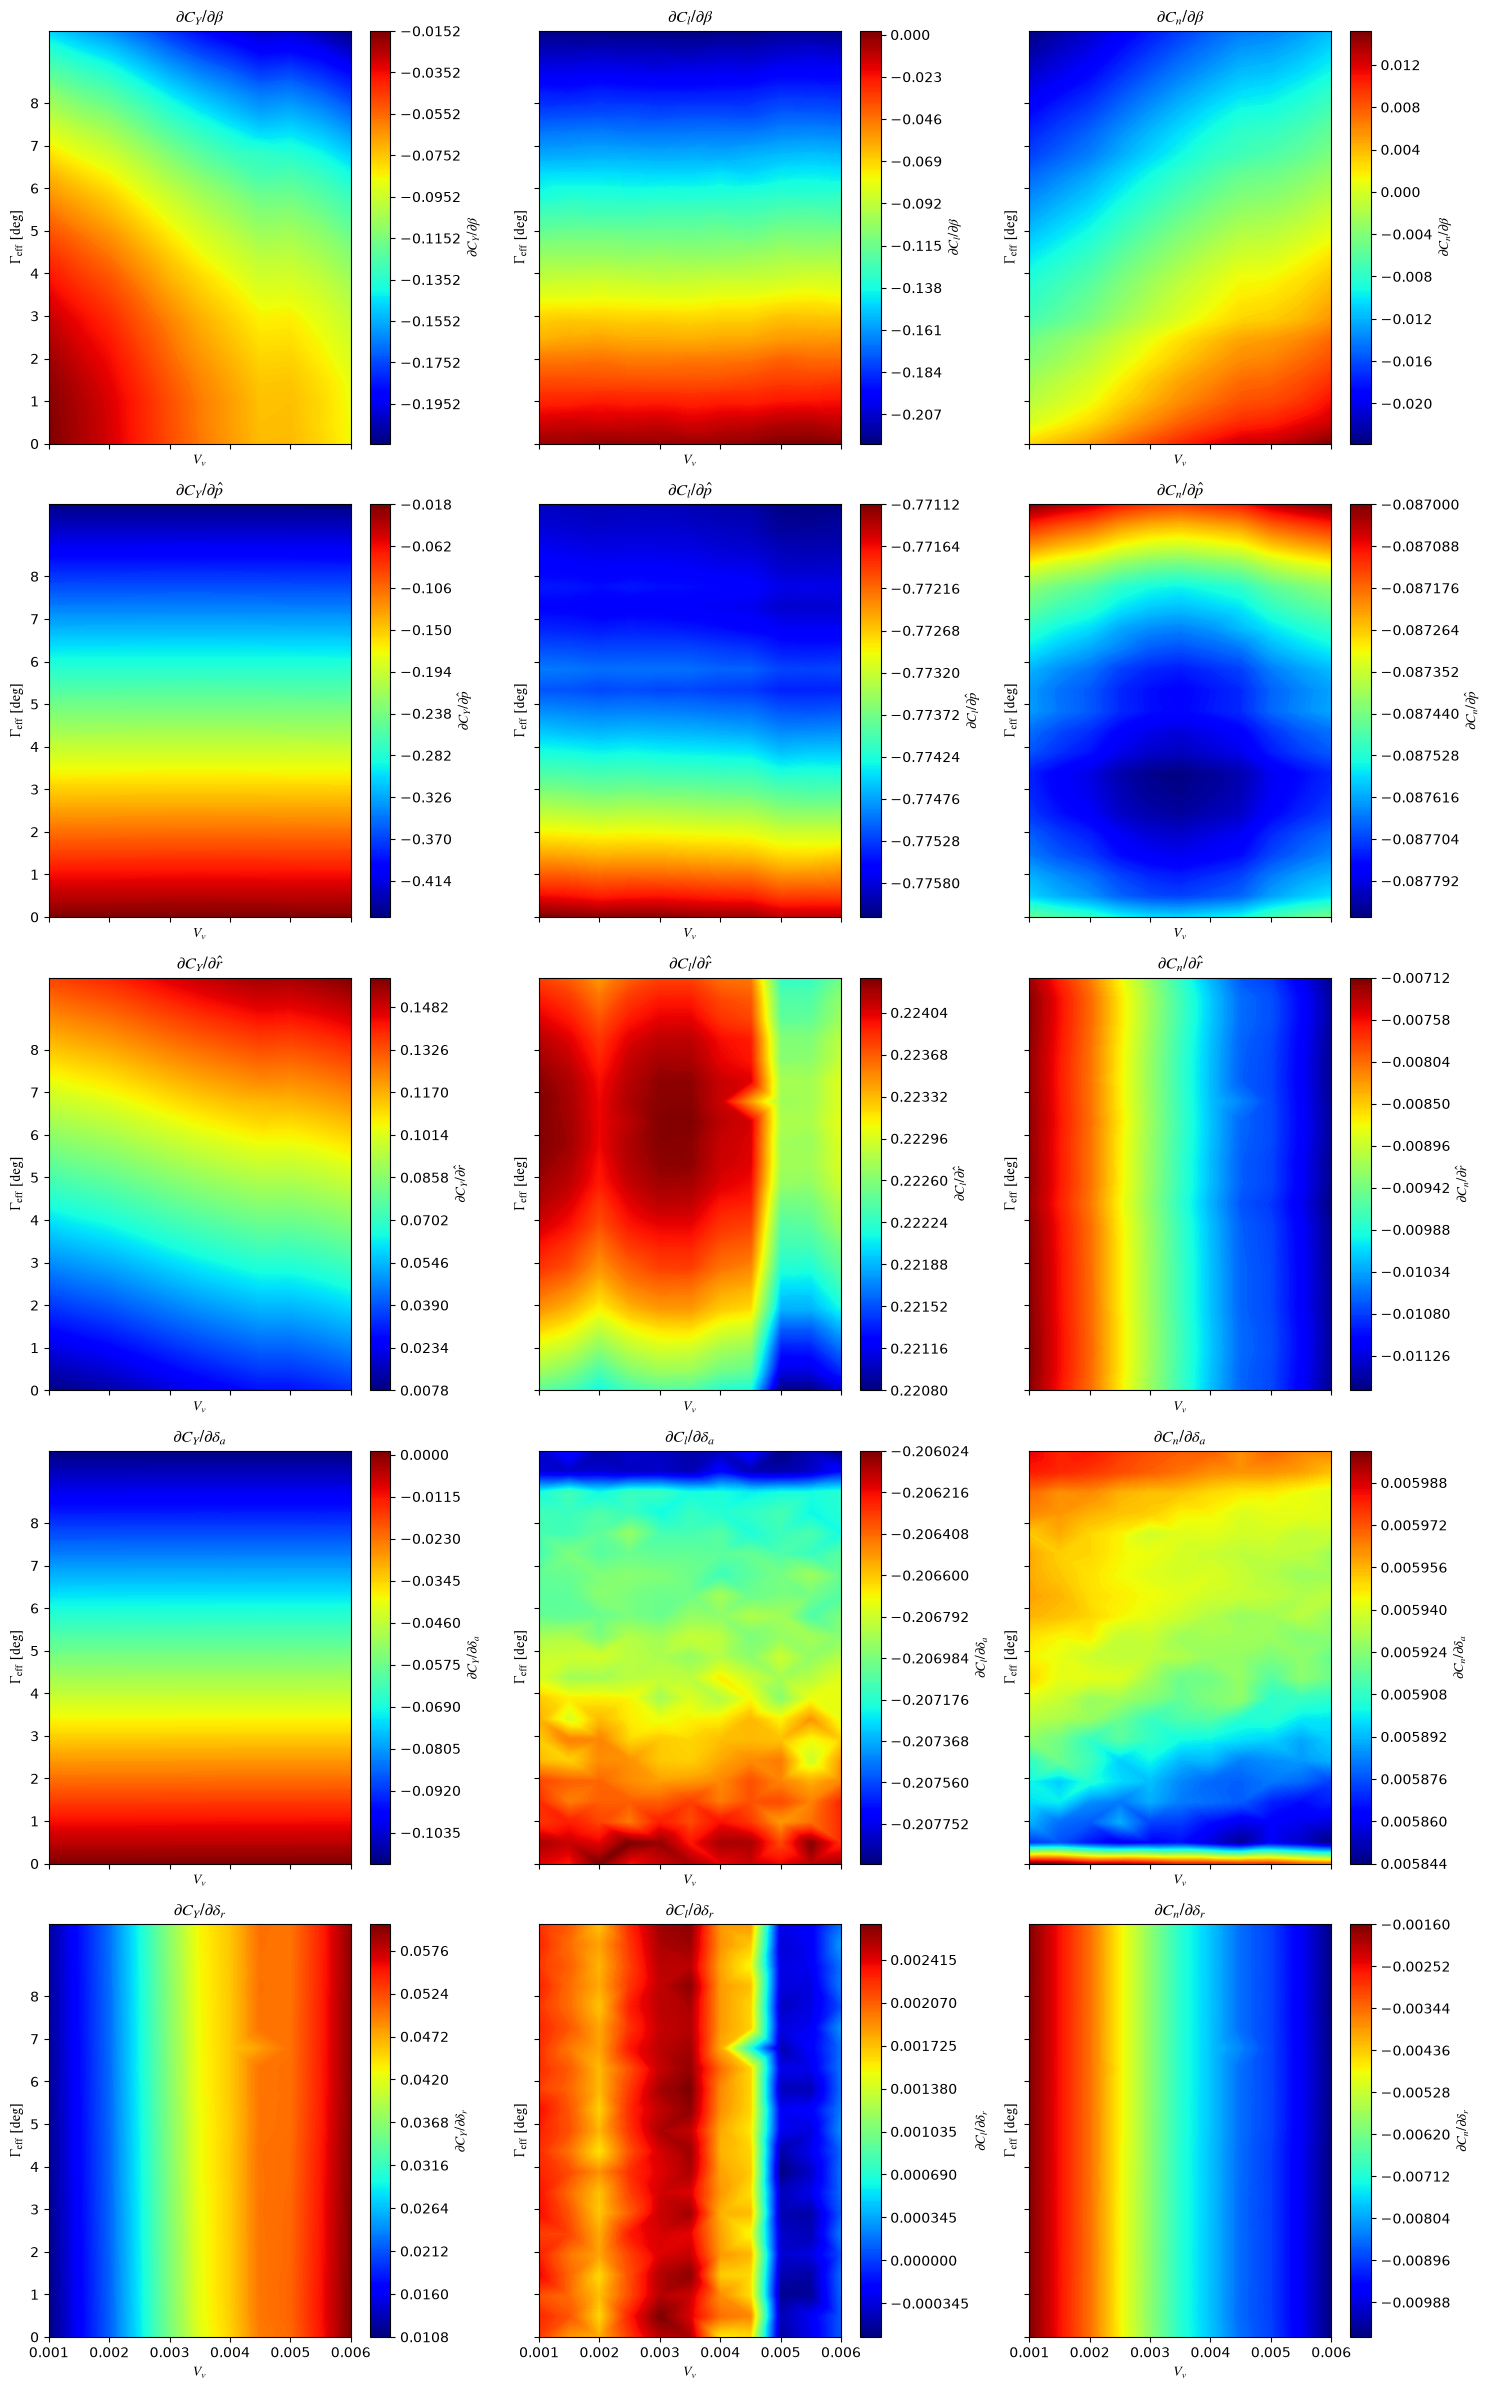

In [10]:
lateral_columns = [
    ("CY", r"C_Y"),
    ("CMl", r"C_l"),
    ("CMn", r"C_n"),
]
derivative_rows = [
    ("Beta", r"\beta"),
    ("p", r"\hat{p}"),
    ("r", r"\hat{r}"),
    (delta_to_congrp["delta_a"], r"\delta_a"),
    (delta_to_congrp["delta_r"], r"\delta_r"),
]

fig, axes = plt.subplots(len(derivative_rows), len(lateral_columns), figsize=(15, 24), sharex=True, sharey=True)

for row_index, (suffix, variable_label) in enumerate(derivative_rows):
    for col_index, (prefix, coefficient_label) in enumerate(lateral_columns):
        column = f"{prefix}_{suffix}"
        label = rf"$\partial {coefficient_label}/\partial {variable_label}$"
        plot_vv_gamma_contour_panel(df, column, ax=axes[row_index, col_index], label=label, **PANEL_KWARGS)

save_figure(fig, "vv_gamma_lateral_derivatives")
plt.show()

## 8. ラダーのみ旋回の評価指標

ラダーのみ旋回でよく見る指標をまとめて描画する。

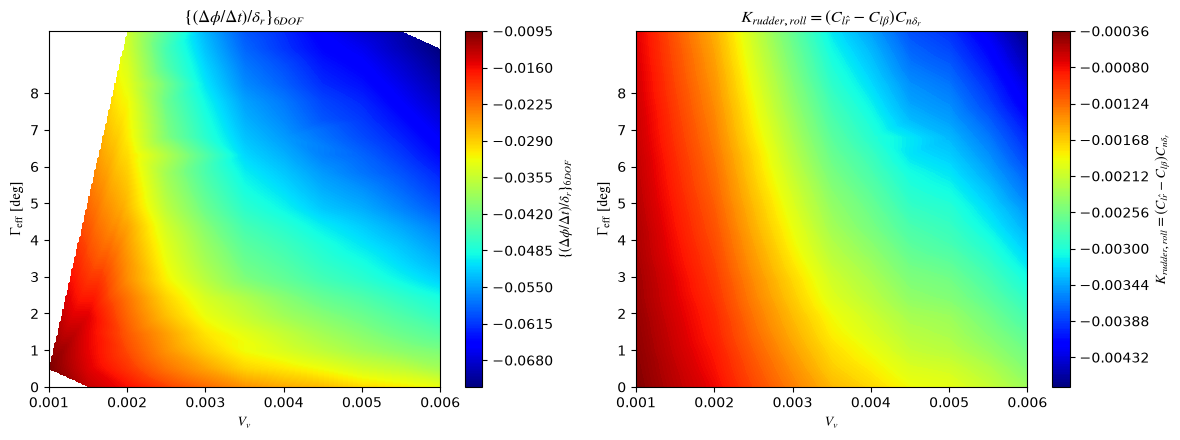

In [11]:

index_panels = [
    ("sixdof_roll_response_phi_rate_per_delta_r", None),
    ('simple_rudder_roll_index', None),
]

# fig, axes = plt.subplots(1, len(index_panels), figsize=(4*len(index_panels), 3), sharex=True, sharey=True)
fig, axes = plt.subplots(1, 2, figsize=(12, 9/2), sharex=False, sharey=False)
for ax, (column, label) in zip(axes.flat, index_panels):
    plot_vv_gamma_contour_panel(df, column, ax=ax, label=label, **PANEL_KWARGS)

save_figure(fig, "vv_gamma_rudder_roll_response")
plt.show()

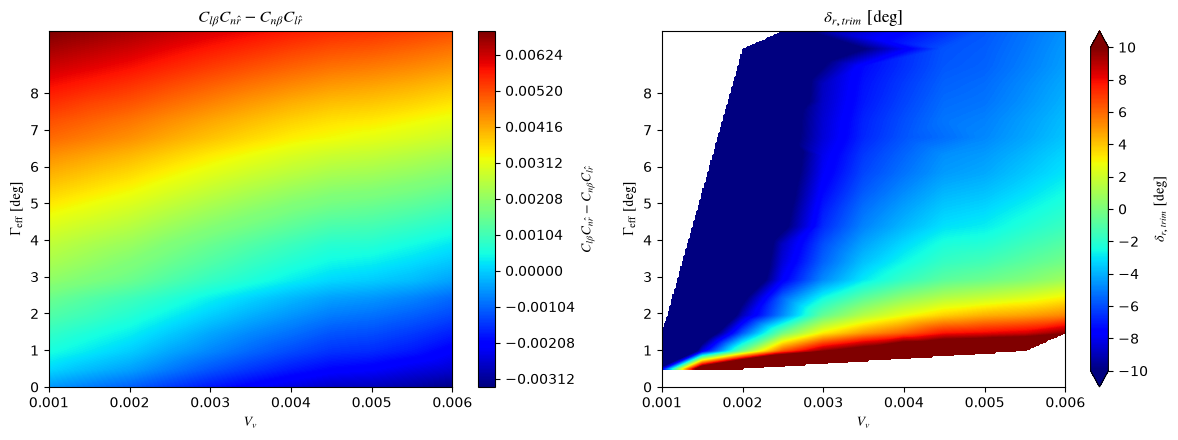

In [12]:

index_panels = [
  ("spiral_margin", None),
  ("turn_trim_delta_r", None),
]

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharex=False, sharey=False)
for ax, (column, label) in zip(axes.flat, index_panels):
    plot_vv_gamma_contour_panel(df, column, ax=ax, label=label, **PANEL_KWARGS)

save_figure(fig, "vv_gamma_spiral_stablity")
plt.show()

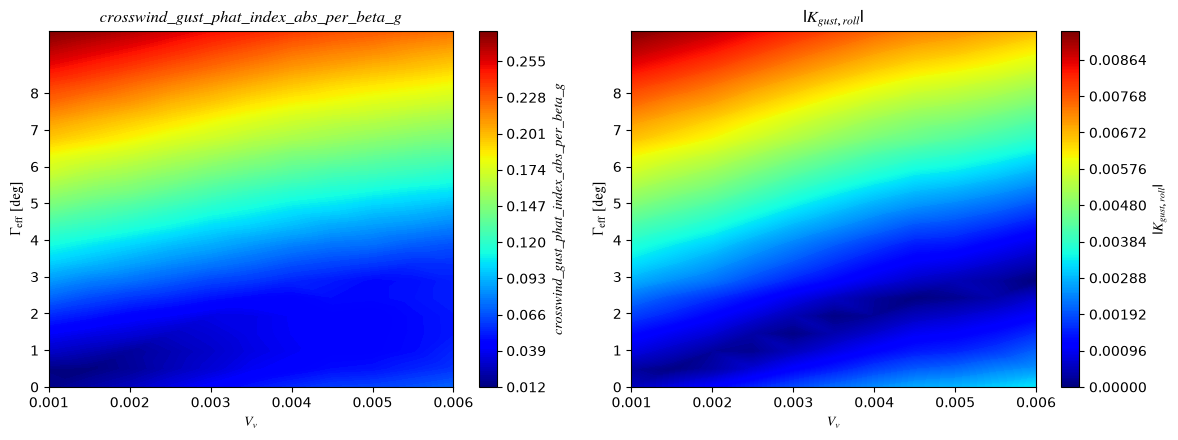

In [18]:

index_panels = [
  ("crosswind_gust_phat_index_abs_per_beta_g", None),
  ("crosswind_gust_roll_index_abs", None),
]

# df_trim = df[df["turn_trim_passed"] == True].copy()
# fig, axes = plt.subplots(1, len(index_panels), figsize=(4*len(index_panels), 3), sharex=True, sharey=True)
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharex=False, sharey=False)
for ax, (column, label) in zip(axes.flat, index_panels):
    plot_vv_gamma_contour_panel(df, column, ax=ax, label=label, **PANEL_KWARGS)

save_figure(fig, "vv_gamma_gust_response")
plt.show()

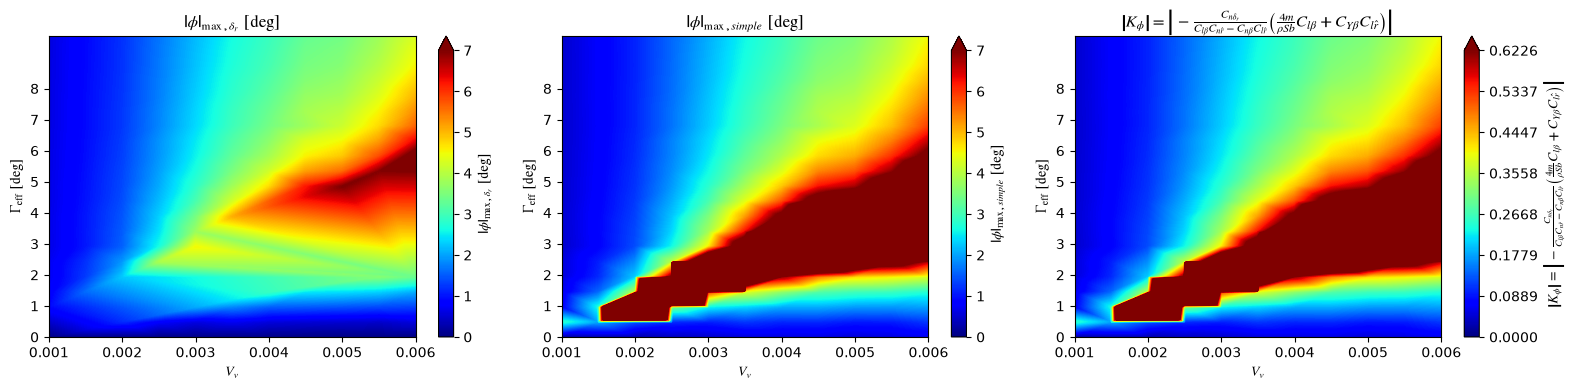

In [14]:
df["simple_rudder_turn_K_phi"] = np.abs(df["simple_rudder_turn_K_phi"].values)
index_panels = [
  ("rudder_limit_turn_max_abs_phi", None),
  ("simple_rudder_limit_turn_max_abs_phi", None),
  ("simple_rudder_turn_K_phi", None),
]

# df_trim = df[df["turn_trim_passed"] == True].copy()
# fig, axes = plt.subplots(1, len(index_panels), figsize=(4*len(index_panels), 3), sharex=True, sharey=True)
fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharex=False, sharey=False)
for ax, (column, label) in zip(axes.flat, index_panels):
    plot_vv_gamma_contour_panel(df, column, ax=ax, label=label, **PANEL_KWARGS)

save_figure(fig, "vv_gamma_rudder_turn_indices")
plt.show()

## 9. 出力ファイル

生成した図は `vv_gamma_chart_plots/` に保存される。

In [15]:
for path in sorted(output_dir.glob("vv_gamma_*")):
    print(path)

vv_gamma_chart_plots\vv_gamma_gust_response.pdf
vv_gamma_chart_plots\vv_gamma_gust_response.png
vv_gamma_chart_plots\vv_gamma_lateral_derivatives.pdf
vv_gamma_chart_plots\vv_gamma_lateral_derivatives.png
vv_gamma_chart_plots\vv_gamma_rudder_roll_response.pdf
vv_gamma_chart_plots\vv_gamma_rudder_roll_response.png
vv_gamma_chart_plots\vv_gamma_rudder_turn_indices.pdf
vv_gamma_chart_plots\vv_gamma_rudder_turn_indices.png
vv_gamma_chart_plots\vv_gamma_rudder_turn_metrics.pdf
vv_gamma_chart_plots\vv_gamma_rudder_turn_metrics.png
vv_gamma_chart_plots\vv_gamma_spiral_stablity.pdf
vv_gamma_chart_plots\vv_gamma_spiral_stablity.png
